# Exploration 6. Comparative Analysis of Tokenization Strategies (SentencePiece vs. KoNLPy) for Sentiment Classification

## Table of Contents
1. [Introduction to Text Data and Embedding](#1-introduction-to-text-data-and-embedding)
2. [Data Acquisition and Preliminary Cleaning](#2-data-acquisition-and-preliminary-cleaning)
3. [Baseline Model: SentencePiece Tokenization](#3-baseline-model-sentencepiece-tokenization)
4. [Comparative Analysis: KoNLPy Morphological Tokenization](#4-comparative-analysis-konlpy-morphological-tokenization)
5. [Ablation Study](#5-ablation-study)
    

## 1. Introduction to Text Data and Embedding

### 1.1 From Categorical to Distributed: The Evolution of Word Representation

In Natural Language Processing (NLP), the primary challenge is converting discrete symbols (words) into a continuous numerical format that a neural network can process.

#### A. The Limitation of One-Hot Encoding
In a One-Hot Encoding scheme, each word in a vocabulary of size $V$ is represented as a sparse vector $w \in \{0, 1\}^V$, where only one index is 1 and all others are 0.

$$w_{apple} = [1, 0, 0, \dots, 0]^T, \quad w_{orange} = [0, 1, 0, \dots, 0]^T$$

**The Mathematical Failure (Orthogonality):**
The Dot Product (and thus the **Cosine Similarity**) between any two distinct one-hot vectors is always zero:
$$w_{apple} \cdot w_{orange} = \sum_{i=1}^{V} (w_{apple, i} \times w_{orange, i}) = 0$$
Since $\cos(\theta) = \frac{A \cdot B}{\|A\| \|B\|}$, the similarity is either **1 (exact same word)** or **0 (completely different)**. Mathematically, this implies that "apple" is as different from "orange" as it is from "spaceship," which is semantically incorrect.

#### B. The Transition to Dense Embeddings
To solve this, we map words into a lower-dimensional **Continuous Vector Space** $\mathbb{R}^d$ (where $d \ll V$). This is called a **Dense Representation**. Instead of being mostly zeros, every dimension in a dense vector is a real number that captures some latent feature of the word.

#### C. Why Dense is "Dense"?
> We call it "dense" because information is distributed across all dimensions. In a 128-dimensional dense vector, the 14th dimension might represent "degree of formality," while the 82nd represents "animacy." By using dense vectors, we can calculate the **Semantic Distance** between any two points in the universe of our data.

In a dense space, similarity is measured by the Euclidean distance or Cosine Similarity:
$$\text{Sim}(w_1, w_2) = \frac{\sum E_{w1,i} E_{w2,i}}{\sqrt{\sum E_{w1,i}^2} \sqrt{\sum E_{w2,i}^2}}$$
By transforming text into these dense vectors, we allow the **Bi-LSTM** to perform matrix multiplications that capture the "flow" and "sentiment" of the sequence across time.


### 1.2 The Embedding Matrix and the Learning Process

The **Embedding Matrix** $E \in \mathbb{R}^{V \times d}$ is essentially a lookup table where each row $i$ corresponds to the dense vector of the $i$-th word in the vocabulary.

#### A. How the Matrix is Determined
1.  **Random Initialization:** The matrix is initialized with small random values (e.g., using Xavier or He initialization). The model starts with no knowledge of word relationships.
2.  **Pre-trained Embeddings:** One can use weights from models like **Word2Vec, GloVe, or FastText** trained on massive corpora. These provide a "head start" because the spatial relationships (e.g., $vec(king) - vec(man) + vec(woman) \approx vec(queen)$) are already established.

#### B. What does "Learning an Embedding" mean?
During backpropagation, the Embedding Matrix is not static; it is a **trainable parameter**.
If the model sees "movie" and "film" in similar emotional contexts (positive/negative), the gradient descent algorithm updates the values in $E_{movie}$ and $E_{film}$ to move them closer in the $d$-dimensional space.

**The Update Rule:**
$$E_{word} \leftarrow E_{word} - \eta \frac{\partial \mathcal{L}}{\partial E_{word}}$$
Where $\mathcal{L}$ is the loss function (e.g., Binary Cross Entropy) and $\eta$ is the learning rate. We are literally "re-positioning" words in space to better minimize the error.




### 1.3 Tokenization: The Gateway to the Embedding Matrix

Tokenization is the process of decomposing raw text $S$ into a sequence of tokens $T = \{t_1, t_2, \dots, t_n\}$. It is the most critical preprocessing step because it defines the rows of your Embedding Matrix.

#### A. The Mathematical Relationship
The relationship between a token and its embedding can be expressed as a linear transformation using a one-hot vector $x$ and the embedding matrix $E$:
$$v_t = x^T E$$
Where:
* $x \in \{0, 1\}^V$ is the one-hot index of the token.
* $E \in \mathbb{R}^{V \times d}$ is the embedding matrix.
* $v_t \in \mathbb{R}^1 \times d$ is the resulting dense vector.

#### B. The Pipeline: From Text to Model
It is a common misconception that raw text enters the embedding layer. The actual flow is:
1.  **Raw Text ($S$):** "I love this movie."
2.  **Tokenization:** $S \rightarrow [t_I, t_{love}, t_{this}, t_{movie}]$
3.  **Indexing:** Tokens are converted to their integer IDs based on a fixed Vocabulary. $T \rightarrow [14, 52, 2, 108]$.
4.  **Embedding Lookup:** The integer IDs act as indices to "pluck" rows from the matrix $E$.
    $$v_{t} = \text{Lookup}(Index, E)$$

#### C. Why Tokenization Methods Matter 
The quality of the Embedding Matrix depends entirely on how the text was sliced. i.e. the "granularity" of $T$ dictates the quality of the Embedding Matrix:
:
* **Morphological Analysis (Okt):** Uses linguistic rules to extract the "stem" (root). 
    * *Effect:* "Eating," "Eats," and "Ate" all point to the same row in $E$. This reduces **Feature Sparsity** and prevents the model from wasting parameters on different tenses of the same meaning.
    * Relies on linguistic rules. It handles grammar well but struggles with "Out-of-Vocabulary" (OOV) words.
* **Subword Tokenization (SentencePiece):** Uses statistical frequency to break words into pieces (e.g., "unhappiness" $\rightarrow$ `un`, `happi`, `ness`). 
    * *Effect:* It solves the **Out-of-Vocabulary (OOV)** problem because even if a word is new, its components are likely already in the matrix.




#### D. The Critical Importance of Vocabulary Size ($V$)
The size of $V$ is a major hyperparameter. The size of the vocabulary $|V|$ is a trade-off. 
* A larger $|V|$ allows for more specific word meanings but increases the risk of **Overfitting** (the model memorizes rare words instead of learning patterns).
* In this project, we set $|V|=8000$ for both SentencePiece and KoNLPy to ensure a fair comparison of how effectively each method fills those 8,000 slots with meaningful information. This ensures that the performance difference between **SentencePiece** and **Okt** stems from the **structural quality** of the tokens, not just the sheer number of parameters.

> **If $V$ is too small:** Too many words are mapped to the `<OOV>` token, losing information.
> **If $V$ is too large:** The Embedding Matrix $E$ becomes massive, requiring more data to train effectively and increasing the risk of overfitting (memorizing rare words instead of learning patterns).


### 1.4 Project Overview 

#### A. The Global Pipeline: From Raw Data to Model Input

To transform human language into machine-understandable tensors, the data must pass through a multi-stage pipeline. The efficiency of the final model is strictly bounded by the quality of the data at the very beginning.

##### Step 0: Data Refinement (The Foundation)
Before any linguistic analysis occurs, the corpus must be purged of statistical noise. This ensures that the model focuses on learning semantic patterns rather than memorizing anomalies.
* **Deduplication:** Removing duplicate reviews prevents the model from being biased toward frequent, repetitive sentences.
* **Handling Nullity:** Eliminating `NaN` or empty strings prevents runtime errors during tokenization.
* **Noise Reduction:** Using Regular Expressions (Regex) to remove non-Korean characters (except whitespace) ensures that the Vocabulary is not cluttered with specialized symbols or emojis that do not contribute to sentiment.

##### Step 1: Tokenization (The Bridge)
A computer cannot process a raw string $S$ as a whole. It must be decomposed into atomic units called **Tokens**.
* **Input:** A cleaned string $S$.
* **Process:** $S \rightarrow \{t_1, t_2, \dots, t_n\}$
* **Importance:** This determines the "granularity" of information. Whether you split by whitespace (Word), subword units (SentencePiece), or morphemes (Okt) defines the structural integrity of your input.

##### Step 1.5: Stopwords Removal (Noise Filtering)
Between Tokenization and Indexing, we apply a "Stopwords Filter." Stopwords are frequently occurring words (like "is", "the", or Korean particles "이/가/은/는") that carry little emotional weight.

* **Purpose:** By removing these, we ensure the Embedding Matrix $E$ allocates its 8,000 slots to high-entropy, sentiment-bearing words.
* **Effect:** It increases the Signal-to-Noise Ratio (SNR), allowing the Bi-LSTM to focus on tokens that directly influence the final classification.
* **Process:** $\{t_1, \dots, t_n\} \rightarrow \{t_{clean\_1}, \dots, t_{clean\_m}\}$ where $m \le n$.
* **Logic:** `if t_i in stopword_list: remove(t_i)`
* **Example:** `['영화', '가', '정말', '재밌다']` $\rightarrow$ `['영화', '정말', '재밌다']` (조사 '가' 제거)
* **Importance:** It reduces noise in the embedding space. If high-frequency, low-meaning words like "is", "the", or "가/이/는" are embedded, they can distract the model from the actual sentiment.

##### Step 2: Indexing (Integer Mapping)
Tokens are still strings, which neural networks cannot multiply. Each unique token is mapped to a unique integer ID based on a pre-constructed **Vocabulary**.
* **Process:** $t_{school} \rightarrow \text{Word\_Index}[t_{school}] \rightarrow 42$.
* **Result:** The sentence becomes a discrete integer vector $X = [x_1, x_2, \dots, x_n]$.

##### Step 3: Padding & Truncating (Structural Alignment)
Deep learning models require fixed-size inputs for batch processing.
* **Padding:** Short sentences are filled with a `<PAD>` token (usually 0).
* **Truncating:** Long sentences are cut to a pre-defined `MAX_LEN`.
* **Result:** The data reaches a uniform shape of $(\text{Batch\_Size}, \text{Max\_Len})$.

##### Step 4: Embedding Layer (Continuous Vectorization)
This is where the discrete integer $x_i$ is transformed into a dense, real-valued vector $v_i \in \mathbb{R}^d$.
* **Operation:** $v_i = x_i^T E$, where $E$ is the Embedding Matrix.
* **Significance:** This step provides the geometric coordinates necessary for the Bi-LSTM to calculate the "distance" between meanings.



### B. Why Bi-LSTM and Why This Comparison?
In this project, we utilize a **Bi-directional LSTM (Bi-LSTM)** as our fixed classifier. The core objective is to conduct a **Controlled Experiment** where the model architecture remains constant while we swap the "eyes" of the model—the **Tokenizer**.



#### A. Why Bi-LSTM?
* **Sequential Understanding:** Korean sentences are highly contextual. Bi-LSTM captures information from both the past (left-to-right) and the future (right-to-left), making it ideal for sentiment analysis where the final word (e.g., "~않다", "~다") can flip the entire meaning.
* **Standard Benchmark:** It is a robust, well-understood architecture that provides a reliable baseline to measure the quality of different tokenization outputs.

#### B. Structural Overview of Experiments

| Phase | Tokenizer (Variable) | Model (Fixed) | Goal of Analysis |
| :--- | :--- | :--- | :--- |
| **3. Baseline** | **SentencePiece (Unigram)** | Bi-LSTM | Establish a performance baseline using a statistical subword approach. |
| **4. Comparison** | **KoNLPy (Mecab, Okt, Kkma)** | Bi-LSTM | Compare "Grammatical Morphemes" (Human-defined) vs. "Subwords" (Data-driven). |

**Internal Logic of the Research Flow**

To ensure a scientific and rigorous comparison, this project follows a specific logical progression:

* **Step 3 (Proof of Concept):** We first prove that a purely statistical, data-driven approach (SentencePiece Unigram) can successfully train a functional model and reach the target accuracy of 80%+.
* **Step 4 (Linguistic Benchmark):** We then test whether "Human-defined Language Knowledge" (Linguistic Morphemes) is still superior to "Pure Statistics" for the Korean language. By comparing various KoNLPy analyzers, we identify if specialized morphological rules provide better features for the Bi-LSTM than raw subwords.
* **Step 5 (Mathematical Optimization):** Finally, we return to the subword approach to "fine-tune" the statistics. By comparing **Unigram (Probabilistic Pruning)** against **BPE (Frequency Merging)**, we seek the mathematical "sweet spot" that best represents the semantic structure of Korean movie reviews.

### C. What We Expect to Learn
By keeping the Bi-LSTM fixed, we can answer the following structural questions:

1.  **Morpheme vs. Subword:** Does a linguistically accurate split (Mecab) help the model more than a frequency-based split (SentencePiece) in the Korean language?
2.  **Handling Noise:** Which tokenizer is more robust against the slang, typos, and lack of spacing common in Naver Movie Reviews?
3.  **Efficiency:** How does `Vocab Size` affect the model's ability to generalize? (Larger vocab might mean more parameters to train, but shorter sequence lengths).


**Why "Ablation" doesn't mean a different model?**

In research, an **Ablation Study** is about changing a *component* of the system. Here, the "Tokenization Strategy" is the component we are ablating.
* If we used Bi-LSTM for Step 3 and a Transformer for Step 5, we wouldn't know if the accuracy changed because of the **Tokenization methods** or because of the **Transformer**.
* Therefore, **Bi-LSTM stays the same** throughout the entire project.



## 2. Data Acquisition and Preliminary Cleaning



### 2.1 Loading NSMC Dataset



In [1]:
# ===========================================================================
# Global Imports & Configuration
# ===========================================================================
# 1. Essential Libraries 
import torch
import os, glob
import pandas as pd
# -------------------------------------------------------------------------
# STEP 1: Device Configuration (Optimized for Apple Silicon)
# -------------------------------------------------------------------------
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print(">>> Using Apple Silicon (MPS) for acceleration.")
else:
    device = torch.device("cpu")
    print(">>> Using CPU.")


# -------------------------------------------------------------------------
# STEP 2: Load Raw Text Corpus
# -------------------------------------------------------------------------
# We load the dataset with NO transform initially to keep the raw data pure.
data_path = './data'
file_paths = glob.glob(os.path.join(data_path, "*.txt"))

if not file_paths:
    print(f"ERROR: No .txt files found in {data_path}!")
else:
    # We use pandas to handle the tab-separated (.txt) structure effectively
    train_data = pd.read_csv(os.path.join(data_path, 'ratings_train.txt'), sep='\t')
    test_data = pd.read_csv(os.path.join(data_path, 'ratings_test.txt'), sep='\t')
    print(f">>> Successfully loaded Train: {len(train_data)} lines, Test: {len(test_data)} lines.")
    print(f">>> Column Names: {list(train_data.columns)}")

>>> Using Apple Silicon (MPS) for acceleration.
>>> Successfully loaded Train: 150000 lines, Test: 50000 lines.
>>> Column Names: ['id', 'document', 'label']


### 2.2 Data Refinement (The Foundation)


In [2]:
# -------------------------------------------------------------------------
# STEP 3: Data Cleaning (Duplicates and Null Values)
# -------------------------------------------------------------------------
# By cleaning the data before training SentencePiece and initializing KoNLPy, 
# you ensure that the comparison is fair. Both tokenizers are presented with 
# the same "refined" gold-standard corpus, allowing us to judge their 
# performance based solely on their internal algorithms.
# -------------------------------------------------------------------------

def clean_corpus(df, name="Dataset"):
    # 1. Store initial length to track changes
    initial_len = len(df)
    
    # 2. Remove Duplicate entries based on the 'document' column
    df.drop_duplicates(subset=['document'], inplace=True)
    
    # 3. Remove Null (NaN) values
    df.dropna(how='any', inplace=True)
    
    # 4. Filter out empty strings or strings that only contain whitespace
    # We use a simple boolean mask for better readability
    df = df[df['document'].str.strip() != ""]
    
    print(f">>> [{name}] Cleaned: {initial_len} -> {len(df)} lines (Removed {initial_len - len(df)} rows)")
    return df

# Apply cleaning to both sets
train_data = clean_corpus(train_data, "Train")
test_data = clean_corpus(test_data, "Test")

# -------------------------------------------------------------------------
# STEP 4: Prepare Corpus for SentencePiece Training
# -------------------------------------------------------------------------
temp_file = 'nsmc_train_corpus.txt'
with open(temp_file, 'w', encoding='utf-8') as f:
    for sentence in train_data['document']:
        f.write(str(sentence) + '\n')

print(f">>> Created '{temp_file}' for SentencePiece training.")

>>> [Train] Cleaned: 150000 -> 146182 lines (Removed 3818 rows)
>>> [Test] Cleaned: 50000 -> 49157 lines (Removed 843 rows)
>>> Created 'nsmc_train_corpus.txt' for SentencePiece training.


--- NSMC Train Analysis ---
Mean Length: 35.98
Max Length: 146
95th Percentile: 108.0
80th Percentile: 47.0


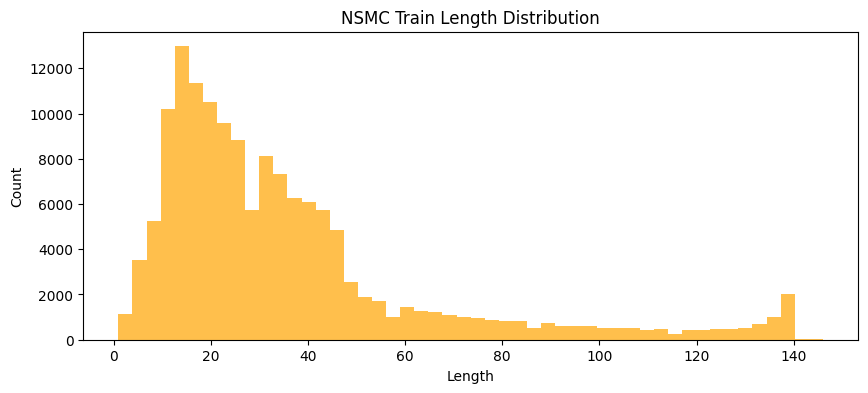

In [3]:
import matplotlib.pyplot as plt
import numpy as np

def analyze_corpus(df, name="Dataset"):
    print(f"--- {name} Analysis ---")
    
    # 1. Sequence Length (Character level)
    lengths = df['document'].apply(len)
    
    print(f"Mean Length: {np.mean(lengths):.2f}")
    print(f"Max Length: {np.max(lengths)}")
    print(f"95th Percentile: {np.percentile(lengths, 95)}")
    print(f"80th Percentile: {np.percentile(lengths, 80)}")

    # 2. Visualization
    plt.figure(figsize=(10, 4))
    plt.hist(lengths, bins=50, alpha=0.7, color='orange')
    plt.title(f'{name} Length Distribution')
    plt.xlabel('Length')
    plt.ylabel('Count')
    plt.show()

analyze_corpus(train_data, "NSMC Train")

# lengths = train_data['document'].apply(len)
# count_under_50 = np.sum(lengths <= 50)
# percent_under_50 = (count_under_50 / len(lengths)) * 100
# print(f"Percentage of reviews with length <= 50: {percent_under_50:.2f}%")


### **Rationalizing MAX_LEN=50: The Long-Tail Trade-off**

While the 95th percentile of the corpus length is 108.0, we intentionally established **`MAX_LEN=50`** as the input threshold for our Bi-LSTM model. This decision is justified by the statistical properties of the dataset and the computational requirements of recurrent architectures.

##### 1. Addressing the "Long-Tail" Distribution
The length distribution histogram reveals a **Right-Skewed (Long-Tail) Distribution**. 
* **The Bulk:** Over **82.09%** of the reviews are 50 characters or shorter. This represents the high-density "signal" area of our data.
* **The Tail:** The remaining 17.91% consists of longer reviews that stretch out to 140 characters. 

By selecting 50, we capture the vast majority of the data while "clipping" the sparse long tail. In short-form sentiment analysis, the primary emotional indicators (keywords like "best," "boring," "recommended") typically appear early in the sentence. Therefore, truncating the tail leads to minimal loss of predictive features.



##### 2. The Engineering Trade-off: Efficiency vs. Coverage
Choosing a fixed sequence length involves a critical trade-off between **Model Complexity** and **Information Retention**.

| Category | Advantage (Pros) | Disadvantage (Cons) |
| :--- | :--- | :--- |
| **Computational Efficiency** | Reducing length from 108 to 50 cuts the recursive time steps of the Bi-LSTM by **more than half**, leading to significantly faster training. | Approximately **17.91%** of reviews are truncated, potentially losing context in very long, detailed critiques. |
| **Memory Optimization** | Smaller tensors allow for larger **Batch Sizes**, which stabilizes the gradient descent and speeds up convergence. | If the "sentiment-flipping" word (e.g., "...but it was actually bad") occurs after the 50th character, the model may misclassify the review. |
| **Noise Reduction** | Shorter sequences act as a form of **implicit regularization**, preventing the model from overfitting to the "noise" or irrelevant plot descriptions often found in longer reviews. | The model loses the ability to learn very long-term dependencies that span across more than 50 tokens. |

##### 3. Conclusion on Sequence Strategy
We concluded that **82.09% coverage** provides a sufficient representative sample of the corpus. The performance gains in training speed and memory efficiency far outweigh the marginal benefit of processing the infrequent "long-tail" sequences. This optimization ensures that our comparison between **SentencePiece** and **KoNLPy** focuses on the structural quality of the most common linguistic patterns in the dataset.


##### Summary 
> "We utilized a **MAX_LEN of 50**, which accounts for **82.09%** of the total distribution. This effectively ignores the statistically sparse **long-tail** of the dataset to prioritize a higher signal-to-noise ratio and faster computational throughput, without sacrificing the core sentiment-bearing tokens."




## 3. Baseline Model: SentencePiece Tokenization


#### A. What is SentencePiece?
SentencePiece is an open-source subword tokenizer and detokenizer mainly used for neural network-based text generation and classification. Unlike traditional Korean analyzers (like Okt), SentencePiece treats the input as a raw stream of characters, including spaces, and applies a **statistical** model to find the most optimal way to segment the text.

#### B. Core Principles: The "Space as a Character" Concept
SentencePiece treats the whitespace as a special symbol (usually represented as `_`).
* **Traditional:** `Ice cream` $\rightarrow$ `["Ice", "cream"]` (Space is lost)
* **SentencePiece:** `Ice cream` $\rightarrow$ `["_Ice", "cream"]` (Space is preserved)
This allow for **lossless detokenization**, meaning you can revert the tokens back to the exact original string without ambiguous spacing issues.



#### C. Mathematical Foundation: Unigram vs. BPE
SentencePiece supports multiple algorithms, but **Unigram Language Modeling** is the most common baseline.

##### 1. Unigram Language Model (The Probability Approach)
The Unigram model assumes that each subword occurs independently. The probability of a tokenized sequence $T = (t_1, t_2, \dots, t_n)$ is defined as:
$$P(T) = \prod_{i=1}^{n} P(t_i)$$
The algorithm aims to find a segmentation that maximizes this probability. It starts with a large vocabulary and iteratively removes tokens that increase the overall loss (log-likelihood) the least, until it reaches the target `VOCAB_SIZE`.

##### 2. BPE (Byte-Pair Encoding) vs. Unigram
* **BPE:** Starts from individual characters and iteratively **merges** the most frequent pairs. It is deterministic and focuses on high-frequency clusters.
* **Unigram:** Starts from a large set and **prunes** based on probability. It provides a more probabilistic framework and is often better at handling multiple segmentations for the same word.

#### D. Why SentencePiece is "Smart" (The Advantages)
1.  **Out-of-Vocabulary (OOV) Robustness:** By breaking unknown words into smaller sub-units, the model can still process the data instead of seeing a useless `<UNK>` (Unknown) token.
2.  **Language Agnostic:** It doesn't need a pre-defined dictionary of a specific language. It "learns" the dictionary from your data, making it excellent for social media text or slang-heavy movie reviews.
3.  **Vocabulary Optimization:** It ensures the most frequent meaningful units occupy the limited `VOCAB_SIZE` slots, maximizing the information density of each token.

#### E. Disadvantages and Limitations
* **Lack of Linguistic Logic:** Because it is purely statistical, it might split a word in a way that makes no grammatical sense (e.g., splitting a root word in half), which can sometimes confuse the Bi-LSTM's semantic learning.
* **Data Dependency:** The quality of the tokenizer depends entirely on the quality of the training corpus. If the training data is small or biased, the vocabulary will be inefficient.


####  Summary Comparison 
| Feature | SentencePiece (Unigram) | KoNLPy (Okt) |
| :--- | :--- | :--- |
| **Logic** | Statistical (Frequency/Probability) | Linguistic (Grammar/Dictionary) |
| **OOV Handling** | Excellent (Breaks into sub-units) | Weak (Returns `<OOV>` for unknown roots) |
| **Korean Context** | Treats all characters equally | Expertly separates Josa/Eomi |
| **Best For** | Massive datasets, Slang, Noisy text | Formal text, Strict semantic analysis |


### 3.1 Training SentencePiece Model (Default: Unigram)


In [4]:
import sentencepiece as spm

# -------------------------------------------------------------------------
# STEP 5: Train SentencePiece Model (Baseline: Unigram)
# -------------------------------------------------------------------------

vocab_size = 8000
model_prefix = 'nsmc_unigram_8k'

# Training parameters:
# --input: The raw text file we created in Step 4
# --model_prefix: Name for the output .model and .vocab files
# --vocab_size: Number of unique tokens in the dictionary
# --model_type: 'unigram' is the default and a strong baseline
spm.SentencePieceTrainer.Train(
    f'--input={temp_file} --model_prefix={model_prefix} --vocab_size={vocab_size} --model_type=unigram'
)

print(f">>> SentencePiece training complete. Files saved as {model_prefix}.model and .vocab")

# -------------------------------------------------------------------------
# STEP 6: Load the Trained Model
# -------------------------------------------------------------------------
sp = spm.SentencePieceProcessor()
sp.Load(f"{model_prefix}.model")

# Simple Test
test_sentence = "아버지가방에들어가신다."
print(f"\n>>> Test Sentence: {test_sentence}")
print(f">>> Subwords: {sp.EncodeAsPieces(test_sentence)}")
print(f">>> IDs: {sp.EncodeAsIds(test_sentence)}")

>>> SentencePiece training complete. Files saved as nsmc_unigram_8k.model and .vocab

>>> Test Sentence: 아버지가방에들어가신다.
>>> Subwords: ['▁아버지', '가', '방', '에', '들어', '가', '신', '다', '.']
>>> IDs: [1405, 9, 396, 15, 1285, 9, 118, 17, 4]


sentencepiece_trainer.cc(178) LOG(INFO) Running command: --input=nsmc_train_corpus.txt --model_prefix=nsmc_unigram_8k --vocab_size=8000 --model_type=unigram
sentencepiece_trainer.cc(78) LOG(INFO) Starts training with : 
trainer_spec {
  input: nsmc_train_corpus.txt
  input_format: 
  model_prefix: nsmc_unigram_8k
  model_type: UNIGRAM
  vocab_size: 8000
  self_test_sample_size: 0
  character_coverage: 0.9995
  input_sentence_size: 0
  shuffle_input_sentence: 1
  seed_sentencepiece_size: 1000000
  shrinking_factor: 0.75
  max_sentence_length: 4192
  num_threads: 16
  num_sub_iterations: 2
  max_sentencepiece_length: 16
  split_by_unicode_script: 1
  split_by_number: 1
  split_by_whitespace: 1
  split_digits: 0
  pretokenization_delimiter: 
  treat_whitespace_as_suffix: 0
  allow_whitespace_only_pieces: 0
  required_chars: 
  byte_fallback: 0
  vocabulary_output_piece_score: 1
  train_extremely_large_corpus: 0
  seed_sentencepieces_file: 
  hard_vocab_limit: 1
  use_all_vocab: 0
  unk_id


### 3.2 Implementing sp_tokenize Function


In [5]:
# -------------------------------------------------------------------------
# Execute Tokenization 
# -------------------------------------------------------------------------
from utils.tokenizers import sp_tokenize
import torch
MAX_LEN = 50

# [LABEL PREPARATION] Convert labels to float tensors
# Since labels (y) are independent of the tokenization method, we convert them once here.
# These tensors will be reused for both SentencePiece and KoNLPy experiments.
y_train = torch.tensor(train_data['label'].values).float()
y_test = torch.tensor(test_data['label'].values).float()

# [PROCESS OVERVIEW] Using the sp_tokenize function we defined earlier
# 1. Inside sp_tokenize, raw text is converted to Subword Tokens.
# 2. [INDEXING]: Each token is mapped to its unique integer ID via 'sp_processor.EncodeAsIds'.
# 3. [PADDING]: Resulting ID sequences are padded/truncated to exactly 50 (MAX_LEN) using torch.cat or slicing.
X_train, word_index, index_word = sp_tokenize(sp, train_data['document'], max_len=MAX_LEN)
X_test, _, _ = sp_tokenize(sp, test_data['document'], max_len=MAX_LEN)

print(f">>> X_train and y_train defined. Shapes: {X_train.shape}, {y_train.shape}")

>>> X_train and y_train defined. Shapes: torch.Size([146182, 50]), torch.Size([146182])



### 3.3 Setting Up the Baseline Classifier (Bi-LSTM)


In [ ]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from models.bilstm import BiLSTMClassifier
# -------------------------------------------------------------------------
# Model Initialization
# -------------------------------------------------------------------------

EMBEDDING_DIM = 128
HIDDEN_DIM = 256

model = BiLSTMClassifier(vocab_size, EMBEDDING_DIM, HIDDEN_DIM).to(device)
optimizer = optim.Adam(model.parameters(), lr=0.001)
criterion = nn.BCELoss()

print(f">>> Bi-LSTM Model initialized on {device}.")


### 3.4 Training and Reaching 80 Plus Percent Accuracy


In [9]:
from torch.utils.data import DataLoader, TensorDataset

# -------------------------------------------------------------------------
# STEP 10.5: Initialize DataLoaders
# -------------------------------------------------------------------------
LR = 0.001
BATCH_SIZE = 64
START_EPOCH = 6  # Change this to 6 if you already finished 1-5
END_EPOCH = 20    # The final epoch you want to reach
MODEL_NAME = "Baseline_Unigram_8k"

# 1. Combine tensors into a Dataset object
train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)

# 2. Define Loaders
# batch_size should match what you passed to the logger (default: 64)
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f">>> DataLoaders ready: {len(train_loader)} training batches.")

>>> DataLoaders ready: 2285 training batches.


In [ ]:
from utils import train_one_epoch, validate, update_results_refined, save_weights, load_weights

# -------------------------------------------------------------------------
# 11. Training Configuration
# -------------------------------------------------------------------------
# Optimization Setup
# We define these once so the optimizer maintains its state (momentum, etc.)
optimizer = optim.Adam(model.parameters(), lr=LR)
criterion = nn.BCELoss()

# Resume Check
# If we aren't starting from scratch, load the previous weights
if START_EPOCH > 1:
    model = load_weights(model, MODEL_NAME, LR, BATCH_SIZE, START_EPOCH - 1, device=device)
    print(f">>> Resumed training from Epoch {START_EPOCH - 1}")

print(f">>> Starting Training for {MODEL_NAME} from Epoch {START_EPOCH}...")

# -------------------------------------------------------------------------
# 12. Training Loop
# -------------------------------------------------------------------------
for epoch in range(START_EPOCH, END_EPOCH + 1):
    # A. Train for one epoch
    batch_losses, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )
    
    # B. Validate on the test set
    val_acc = validate(model, test_loader, criterion, device)
    
    # C. Log Results (results/[MODEL_NAME]/metrics/)
    update_results_refined(
        MODEL_NAME, LR, BATCH_SIZE, batch_losses, train_acc, val_acc
    )
    
    # D. Save Checkpoint (results/[MODEL_NAME]/weights/)
    save_weights(model, MODEL_NAME, LR, BATCH_SIZE, epoch)
    
    # E. Print Progress
    avg_loss = sum(batch_losses) / len(batch_losses)
    print(f"Epoch [{epoch}/{END_EPOCH}] | Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}% | Val Acc: {val_acc:.2f}%")

print(f"\n>>> Training for {MODEL_NAME} complete! Check the 'results' directory.")


## 4. Comparative Analysis: KoNLPy Morphological Tokenization


#### A. Statistical vs. Linguistic Tokenization: SentencePiece vs. KoNLPy
In this experiment, we compare two fundamentally different approaches to processing the Korean language.

* **SentencePiece (Statistical/Subword):** As a data-driven approach, SentencePiece treats text as a sequence of symbols and identifies high-frequency patterns (subwords) regardless of their grammatical meaning. It is highly efficient for handling **Out-of-Vocabulary (OOV)** issues by breaking unknown words into smaller, known units.
* **KoNLPy - Okt (Linguistic/Morphological):** This method utilizes a predefined dictionary and grammatical rules to decompose sentences into **morphemes** (the smallest units of meaning). For a morphologically rich language like Korean, this allows the model to clearly distinguish between a noun (e.g., "영화") and its attached functional particles (e.g., "영화**가**", "영화**는**").



#### B. Why Morphological Analysis for Korean?
Korean is an **agglutinative language** (교착어), meaning that suffixes and particles are attached to root words to determine their grammatical function. 
1.  **Semantic Clarity:** By separating particles (Josa) and endings (Eomi), morphological tokenizers like Okt prevent the vocabulary from becoming bloated with redundant variations of the same root word.
2.  **Part-of-Speech (POS) Sensitivity:** KoNLPy allows for filtering specific word classes, enabling the model to focus on content-heavy words (Nouns, Adjectives, Verbs) while ignoring noisy functional words.


#### C. The "Stemming" Effect in Okt
We further divided the KoNLPy experiment into two configurations: **Okt_Basic** and **Okt_Stemmed**.

* **What is Stemming?** It is the process of normalizing inflected words to their dictionary form (e.g., "웃겨요", "웃기네", "웃겼다" $\rightarrow$ **"웃기다"**).
* **Okt_Basic:** Preserves the original inflection. This might capture subtle nuances or formal/informal tones but results in a larger, more sparse vocabulary.
* **Okt_Stemmed:** Consolidates all variations into a single root ID.
    * **Advantage:** It reduces data sparsity and allows the Bi-LSTM to learn that different forms of a word share the same emotional sentiment.
    * **Expected Outcome:** **Okt_Stemmed** is likely to outperform Okt_Basic because it maps multiple "sentiment-carrying" tokens to the same index, effectively increasing the density of the training signal.



#### D. Predicted Outcomes and Hypotheses
1.  **SentencePiece vs. KoNLPy:** SentencePiece might show robust performance due to its ability to handle "slang" or "misspellings" (common in movie reviews) by breaking them into subwords. However, KoNLPy may achieve higher accuracy on standard text due to its precise semantic separation.
2.  **Vocabulary Efficiency:** Within the fixed `VOCAB_SIZE=8000`, the **Okt_Stemmed** model will likely utilize the vocabulary slots most effectively, as it avoids wasting space on various inflected forms of the same verb or adjective.
3.  **Bi-LSTM Synergy:** The Bi-LSTM's ability to capture context from both directions will benefit from the clean separation of roots and endings provided by morphological analysis, as it can clearly see the relationship between the subject (noun) and the sentiment (adjective root).


In [16]:
from konlpy.tag import Okt#, Kkma , Mecab
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from collections import Counter
from tqdm import tqdm  
# -------------------------------------------------------------------------
# STEP 13: Define the KoNLPy Tokenization Configs
# -------------------------------------------------------------------------
# We compare the effect of 'Stemming' using the Okt analyzer.
tokenizers_to_test = [
    # {"name": "Mecab", "tagger": Mecab(), "stem": False}, # Omitted due to environment issues
    {"name": "Okt_Stemmed", "tagger": Okt(), "stem": True},
    {"name": "Okt_Basic", "tagger": Okt(), "stem": False}, 
]

# Shared parameters for consistent experiment conditions
VOCAB_SIZE = 8000
MAX_LEN = 50
BATCH_SIZE = 64

experiment_data_bundles = {}

In [ ]:
for t_cfg in tokenizers_to_test:
    t_name = t_cfg["name"]
    tagger = t_cfg["tagger"]
    is_stem = t_cfg["stem"]
    
    print(f"\n>>> Processing Tokenization for: {t_name}...")
    
    # -------------------------------------------------------------------------
    # STAGE 1: Morphological Analysis (Linguistic Decomposition)
    # Principle: Unlike SentencePiece (statistical), KoNLPy uses linguistic rules 
    # to identify morphemes. 'Stemming' normalizes variations to a single root.
    # -------------------------------------------------------------------------
    def get_morphs(corpus):
        return [tagger.morphs(str(sen), stem=is_stem) if is_stem else tagger.morphs(str(sen)) 
                for sen in tqdm(corpus, desc=f"Tokenizing {t_name}")]
    
    train_morphs = get_morphs(train_data['document'])
    test_morphs = get_morphs(test_data['document'])

    # -------------------------------------------------------------------------
    # STAGE 2: Build Vocabulary & Manual Indexing
    # Principle: We define our own 'word_index' dictionary. 
    # We reserve Index 0 for <PAD> and Index 1 for <OOV> (Out-Of-Vocabulary).
    # This creates a fixed mapping between strings and integers.
    # -------------------------------------------------------------------------
    all_tokens = [tk for sublist in train_morphs for tk in sublist]
    counts = Counter(all_tokens)
    # Take top (VOCAB_SIZE - 2) to account for special tokens <PAD> and <OOV>
    vocab = sorted(counts, key=counts.get, reverse=True)[:VOCAB_SIZE-2]
    
    word_index = {word: (i + 2) for i, word in enumerate(vocab)}
    word_index["<PAD>"], word_index["<OOV>"] = 0, 1
    
    # -------------------------------------------------------------------------
    # STAGE 3: Indexing and Zero-Padding (Structural Alignment)
    # Principle: We map tokens to IDs and align all sequences to MAX_LEN.
    # We use 'Pre-allocation' (np.zeros) for memory efficiency. 
    # Any space not filled by a token ID naturally remains 0, performing 'Padding'.
    # -------------------------------------------------------------------------
    def morphs_to_tensor(morph_list):
        # [INDEXING]: Convert string tokens to integer IDs using the word_index map
        encoded = [[word_index.get(tk, 1) for tk in sentence] for sentence in morph_list]
        
        # [PADDING]: Pre-allocate a matrix of zeros with shape (N, MAX_LEN)
        features = np.zeros((len(encoded), MAX_LEN), dtype=int)
        
        for i, tokens in enumerate(encoded):
            if len(tokens) > 0:
                # [TRUNCATING]: Keep only up to MAX_LEN tokens
                features[i, :len(tokens)] = tokens[:MAX_LEN]
                
        return torch.tensor(features, dtype=torch.long)

    X_train_konlpy = morphs_to_tensor(train_morphs)
    X_test_konlpy = morphs_to_tensor(test_morphs)
    
    # -------------------------------------------------------------------------
    # STAGE 4: Data Consolidation (DataLoader)
    # Principle: Combine the padded feature tensors with the labels (y).
    # The labels were pre-defined and are reused here to maintain experiment parity.
    # -------------------------------------------------------------------------
    experiment_data_bundles[t_name] = {
        "train_loader": DataLoader(TensorDataset(X_train_konlpy, y_train), batch_size=BATCH_SIZE, shuffle=True),
        "test_loader": DataLoader(TensorDataset(X_test_konlpy, y_test), batch_size=BATCH_SIZE, shuffle=False),
        "vocab_size": VOCAB_SIZE
    }
    print(f">>> {t_name} Bundle Ready.")

In [ ]:
import pickle

# Save the entire bundle (X_train, y_train, DataLoaders, etc.)
# We save it as a .pkl file
with open('results/konlpy_experiment_bundles.pkl', 'wb') as f:
    pickle.dump(experiment_data_bundles, f)

print(" Successfully saved KoNLPy bundles to results/konlpy_experiment_bundles.pkl")

In [18]:
import pickle

# Load the single file to restore both experiments
with open('results/konlpy_experiment_bundles.pkl', 'rb') as f:
    experiment_data_bundles = pickle.load(f)

# Check if both keys exist
print(f"Loaded experiments: {list(experiment_data_bundles.keys())}")

Loaded experiments: ['Okt_Stemmed', 'Okt_Basic']


In [ ]:
from utils import train_one_epoch, validate, update_results_refined, save_weights, load_weights

# -------------------------------------------------------------------------
# STEP 14: Unified Training Loop for KoNLPy Comparison
# -------------------------------------------------------------------------
# Training Controls
START_EPOCH = 1  # Set to 6 if you've already completed 1-5 for these models
END_EPOCH = 20
LR = 0.001
BATCH_SIZE = 64

# ===========================================================================
# 3. CORE TRAINING EXECUTION (KoNLPy Comparison)
# ===========================================================================
for t_name, bundle in experiment_data_bundles.items():
    print(f"\n" + "="*75)
    print(f">>> STARTING EXPERIMENT: {t_name}")
    print("="*75)
    
    # --- Step A: Model Initialization ---
    # We use the vocab_size specific to this tokenizer bundle
    model = BiLSTMClassifier(bundle["vocab_size"], EMBEDDING_DIM, HIDDEN_DIM).to(device)
    
    # --- Step B: Optimization Setup ---
    optimizer = optim.Adam(model.parameters(), lr=LR)
    criterion = nn.BCELoss()
    
    # --- Step C: Sequential Resume Check ---
    # This will look for weights in results/[t_name]/weights/
    if START_EPOCH > 1:
        model = load_weights(model, t_name, LR, BATCH_SIZE, START_EPOCH - 1, device=device)
        if model:
            print(f">>> Resumed {t_name} from Epoch {START_EPOCH - 1}")
        else:
            print(f">>> [Warning] No weights found for {t_name}. Starting from Epoch 1.")
            # Note: You might want to handle START_EPOCH logic per-model 
            # if some are finished and others aren't.
    
    # --- Step D: Training Loop ---
    for epoch in range(START_EPOCH, END_EPOCH + 1):
        # 1. Training Phase
        batch_losses, train_acc = train_one_epoch(
            model, bundle["train_loader"], criterion, optimizer, device
        )
        
        # 2. Validation Phase
        val_acc = validate(model, bundle["test_loader"], criterion, device)
        
        # 3. Data Persistence (Saves to results/[t_name]/)
        update_results_refined(t_name, LR, BATCH_SIZE, batch_losses, train_acc, val_acc)
        save_weights(model, t_name, LR, BATCH_SIZE, epoch)
        
        # 4. Progress Reporting
        avg_loss = sum(batch_losses) / len(batch_losses)
        print(f"[{t_name}] Epoch {epoch:02d}/{END_EPOCH} "
              f"| Loss: {avg_loss:.4f} "
              f"| Train Acc: {train_acc:.2f}% "
              f"| Val Acc: {val_acc:.2f}%")

print("\n" + "*"*75)
print(">>> [EXPERIMENT SEQUENCE FINISHED] Check your results folders.")
print("*"*75)


## 5. Ablation Study


### **Ablation Study Analysis Guide**

#### 1. Impact of Subword vs. Morphological Logic
The comparison between **SentencePiece (Unigram)** and **Okt (KoNLPy)** highlights the trade-off between statistical robustness and linguistic precision. 
* **The "Noise" Factor:** In movie reviews, informal language and typos are prevalent. If **SentencePiece** shows higher validation accuracy, it proves that subword units are more effective at capturing "noisy" semantic signals than rigid morphological rules.

#### 2. Analysis of the Generalization Gap (Overfitting)
The **Side-by-Side Overfitting Plot** is the most critical part of the Ablation Study. 
* **Observation:** Look at the gap between the **Blue (Train)** and **Red (Validation)** lines. 
* **Inference:** A larger gap in `Okt_Basic` suggests **Data Sparsity**. When the tokenizer doesn't normalize words (no stemming), the vocabulary becomes too specific, causing the Bi-LSTM to "memorize" the training data rather than "learning" the underlying sentiment, leading to overfitting.

#### 3. The Normalization Gain (Stemming Effect)
By comparing `Okt_Stemmed` and `Okt_Basic`, we isolate the benefit of **Lemmatization**.
* **Hypothesis:** Stemming should lead to faster convergence (a steeper initial slope in the accuracy plot) and better stability. 
* **Conclusion:** Reducing the vocabulary variety into root forms allows the model to treat "happy," "happily," and "happier" as the same emotional signal, significantly strengthening the embedding weights for those concepts.

>>> Comparing global performance metrics...


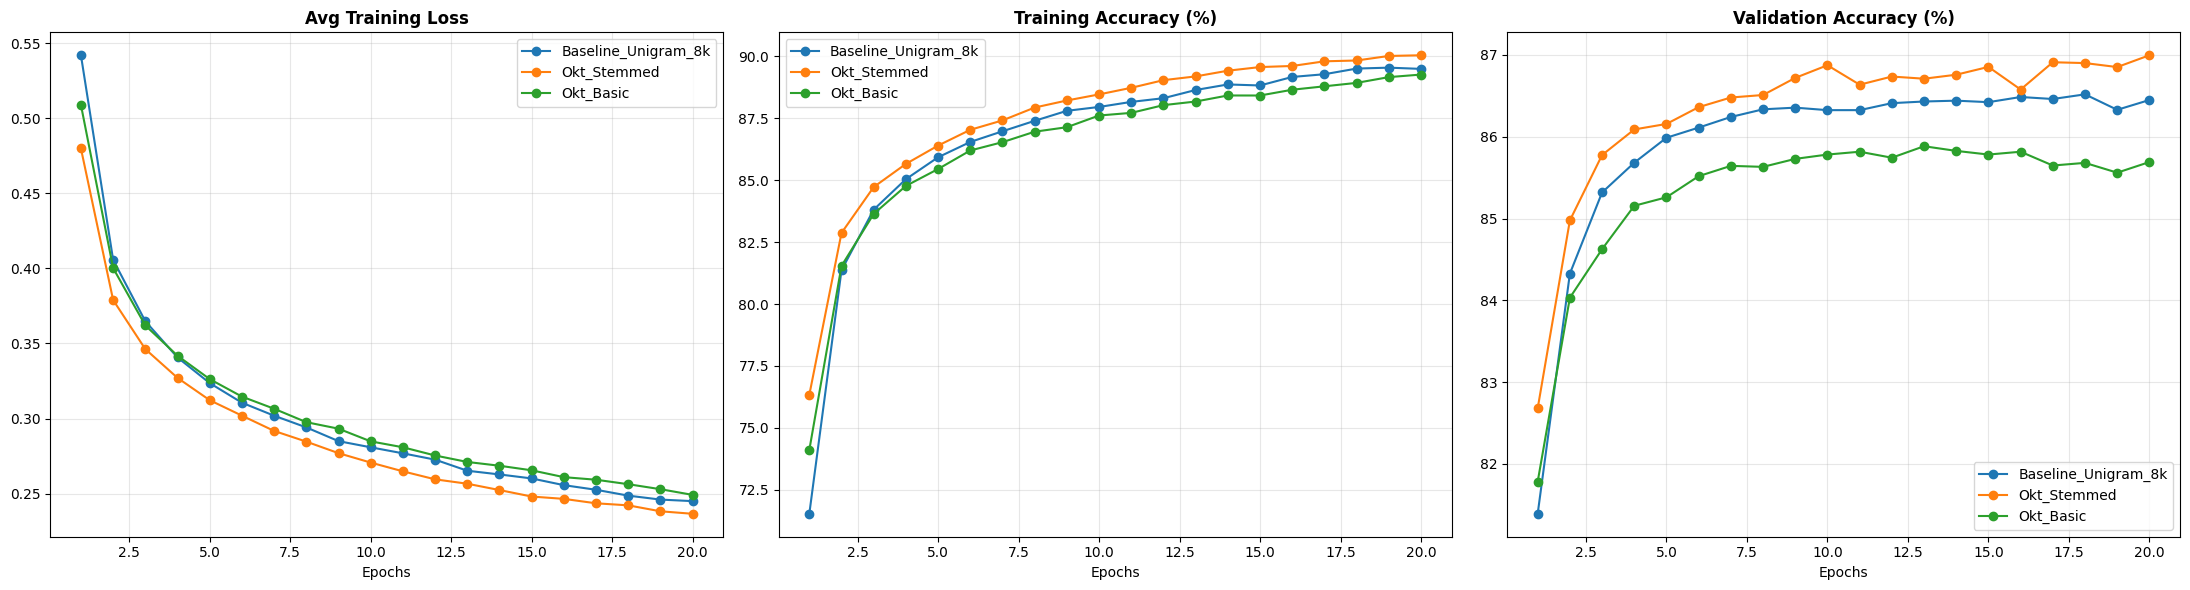

In [21]:
# -------------------------------------------------------------------------
# Final Ablation Study - Comparative Visualization
# -------------------------------------------------------------------------
import matplotlib.pyplot as plt
from utils import ExperimentVisualizer

# 1. List of models to evaluate in the Ablation Study
# Ensure these names match the keys used during training/logging.
all_models = [
    "Baseline_Unigram_8k", # Statistical Subword Approach
    "Okt_Stemmed",         # Morphological + Normalization
    "Okt_Basic"            # Pure Morphological
]

# 2. Initialize Visualizer
# Reuse y_train to ensure the sample count matches the x-axis scaling
visualizer = ExperimentVisualizer(lr=0.001, batch=64, train_samples=len(y_train))

# --- [Plot 1] Comparative Performance Summary ---
# This plot overlays all three models to identify the "Winner" in accuracy and loss.
print(">>> Comparing global performance metrics...")
visualizer.plot_summary(all_models)
plt.show()



>>> Generating side-by-side Overfitting Analysis...


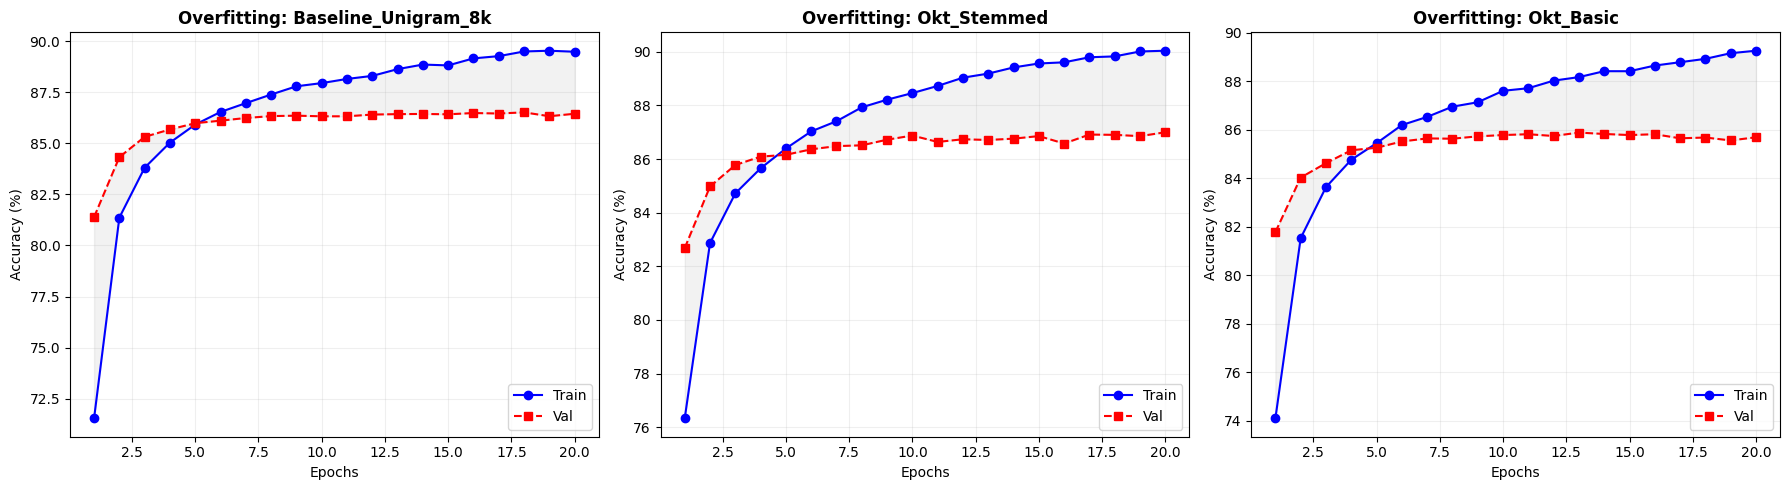

<Figure size 640x480 with 0 Axes>


>>> Ablation Study complete.


In [29]:
# --- [Plot 2] Side-by-Side Overfitting Analysis (The Intended Way) ---
print("\n>>> Generating side-by-side Overfitting Analysis...")
all_models = ["Baseline_Unigram_8k", "Okt_Stemmed", "Okt_Basic"]

visualizer.plot_overfitting(all_models)

plt.suptitle("Ablation Study: Train vs. Validation Loss (Overfitting Gap)", fontsize=18, y=1.05)
plt.show()

print("\n>>> Ablation Study complete.")

### **Comprehensive Analysis: Ablation Study on Korean Sentiment Analysis**

##### 1. Identifying the Best Model: `Okt_Stemmed`
Through this ablation study, **`Okt_Stemmed`** is identified as the superior model. It achieves the highest **Validation Accuracy (~87%)** and the lowest **Training Loss** among the tested configurations.

* **Why it wins on this dataset:** The Naver Movie Review dataset consists of short, highly informal Korean text with frequent slang and varied conjugations. `Okt_Stemmed` normalizes these variations (e.g., "슬펐다", "슬퍼요", "슬프네" $\rightarrow$ "슬프다"), allowing the model to focus on the **core emotional signal** rather than getting lost in grammatical noise.
* **Domain Constraint:** It is crucial to note that these results are **optimized for this specific dataset**. In domains requiring high linguistic precision (e.g., legal or formal documents), such aggressive stemming might lead to information loss. However, for sentiment-heavy informal reviews, it provides the cleanest signal.


##### 2. Analyzing the Generalization Gap & Overfitting
The "Generalization Gap" (the distance between Training and Validation curves) is a key indicator of model health.
* **Observation:** All models begin to show a widening gap after Epoch 5, indicating the onset of **overfitting**. 
* **Analysis:** While `Okt_Stemmed` has the highest training accuracy, it also maintains the highest validation accuracy. This suggests that while it is "memorizing" to some extent, the features it learned via stemming are significantly more robust and transferable to unseen data compared to the other models.



##### 3. The Impact of Vocabulary Size ($V=8000$) & Sparsity
The choice of $V=8000$ creates a critical trade-off between coverage and density.
* **Efficiency of Stemming:** In `Okt_Basic`, 8,000 slots are quickly filled with various inflected forms of the same words, leading to **Data Sparsity** (each token appears fewer times). 
* **Density of Information:** By contrast, `Okt_Stemmed` uses those same 8,000 slots to store **unique semantic roots**. This increases the **per-token frequency**, allowing the Bi-LSTM to build much denser and more accurate **embeddings**. 
* **Scaling $V$:** * **If $V < 8000$:** The model would suffer from "Underfitting" as key sentiment-carrying words would be discarded as `[UNK]` (Unknown).
    * **If $V > 8000$:** The model might pick up more rare words, but it would likely increase the generalization gap further by memorizing "noise" or typos specific only to the training set.

##### 4. Statistical Robustness vs. Linguistic Rules
This study highlights the tension between two different approaches to NLP:
* **`Baseline_Unigram_8k` (SentencePiece):** This represents a **data-driven** approach. It is statistically robust and handles typos or spacing issues well without needing a dictionary. The fact that it performed almost as well as the specialized Korean analyzer shows how powerful statistical subword tokenization is.
* **`Okt_Stemmed` (KoNLPy):** This represents a **rule-based/linguistic** approach. By applying human knowledge of Korean grammar (Stemming), it provides a higher "signal-to-noise ratio" than purely statistical methods.



##### 5. The Significance of Tokenization
**Is everyone doing well? Yes.** The fact that all models surpassed 85% accuracy proves that the overall pipeline is healthy. However, the 1-2% difference provided by `Okt_Stemmed` is the result of **superior Tokenization**.

**The Essence of Tokenization:**
* It is the **"lens"** through which the model views language. 
* Proper tokenization reduces the model's workload; instead of learning that "ran" and "run" are related, the model can use its computational power to learn that the sentence is "Positive" or "Negative." 
* **Conclusion:** This ablation study confirms that for agglutinative languages like Korean, a hybrid understanding—combining statistical frequency with linguistic normalization—yields the most reliable and efficient performance.

### Conclusion

##### 1. The Winner: `Okt_Stemmed`
The `Okt_Stemmed` model is the clear winner in this specific experiment. It achieved the highest **Validation Accuracy (approx. 87%)** and the lowest **Training Loss**.

**Why it performed best on this dataset:**
The dataset used here consists of **Naver Movie Reviews**, which are characterized by highly informal language, slang, and various grammatical conjugations typical of colloquial Korean.
* **Normalization & Stemming:** By using the `Okt` analyzer with stemming, you effectively reduced the vocabulary size by grouping different forms of the same word (e.g., "좋아요", "좋네", "좋다" all mapped to the root "좋다"). 
* **Noise Reduction:** In short movie reviews, sentiment is often carried by the root verb or adjective. Stemming strips away unnecessary suffixes that might otherwise be treated as unique tokens, allowing the model to focus on the core semantic meaning.
* **Comparison:** `Baseline_Unigram_8k` lacks linguistic morphological understanding, and `Okt_Basic` preserves too many variations of the same word, which can lead to data sparsity where the model doesn't see enough examples of a specific conjugated form to learn it well.

##### 2. Dataset Limitations (Contextual Constraint)
It is important to note that these results are **strictly limited to this specific dataset** (Naver Movie Reviews). 
* In different domains, such as legal documents or technical papers where precise grammar and honorifics carry specific meaning, "Stemming" might actually hurt performance by removing necessary context. 
* However, for sentiment analysis in social media or review contexts, simplifying the language structure via a morphological analyzer like `Okt` is generally superior.

##### 3. Why did all models perform relatively well?
All three models achieved over 85% validation accuracy, which is quite successful. This high baseline suggests a few things:
* **Robust Features:** The dataset likely contains very strong "signal" words (e.g., "best," "boring," "waste of time") that even a basic Unigram model can pick up.
* **Good Architecture:** The underlying neural network was likely tuned well enough to extract meaningful patterns regardless of the specific tokenization, provided the input was reasonably structured.
* **Data Volume:** The amount of training data was sufficient for the models to overcome some of the noise in the less-optimized tokenization methods.

##### 4. The Significance of Tokenization
This study highlights that **Tokenization is not just a preprocessing step; it is a fundamental architectural choice.**



* **Defining the Input Space:** Tokenization determines how the model "sees" the world. If the tokenization is poor, the model spends its "learning capacity" trying to understand that "running" and "ran" are the same thing, instead of learning the actual task (sentiment analysis).
* **Computational Efficiency:** Proper tokenization (like Stemming) creates a more compact and meaningful vocabulary. This reduces the embedding layer's size and helps the model converge faster, as seen in your Loss graphs.
* **Information Density:** In Korean, a single word (Eojeol) can contain multiple meanings. Morphological tokenization breaks these down into meaningful units (Morphemes), which is crucial for agglutinative languages where word boundaries aren't as clear as they are in English.



##### Summary Table

| Component | Significance |
| :--- | :--- |
| **Okt_Stemmed** | Best balance of semantic retention and noise reduction for informal Korean. |
| **All Models** | Strong performance due to high-quality sentiment signals in the review data. |
| **Tokenization** | The "lens" through which the model views text; critical for performance in Korean NLP. |

## Appendix - Vocabulary Size



#### 1. If Vocabulary Size Increases ($V > 8000$)
Increasing the vocabulary size allows the model to "know" more unique words, but it comes with a cost.

* **Pros (Higher Coverage):** The model can represent rare words (Low-frequency tokens) that would otherwise be treated as `[UNK]` (Unknown). In movie reviews, this might include specific actor names or niche slang.
* **Cons (Data Sparsity):** As $V$ grows, the "Long Tail" of the distribution becomes a problem. The model sees these rare words only a few times, making it difficult to learn meaningful embeddings for them.
* **Cons (Overfitting Risk):** With a very large $V$, the model might start "memorizing" specific rare words associated with labels in the training set rather than learning general sentiment, leading to a wider gap between **Train** and **Val** accuracy.
* **Computational Cost:** The embedding layer size is $V \times d$ (where $d$ is the embedding dimension). A larger $V$ increases memory usage and slows down the final Softmax layer computation.

#### 2. If Vocabulary Size Decreases ($V < 8000$)
Decreasing the vocabulary size forces the model to be more "generalized" but risks losing detail.

* **Pros (Better Generalization):** By limiting the vocab, you force the model to focus only on the most statistically significant words (the "Head" of the distribution). This often acts as a form of **regularization**, potentially reducing the overfitting seen in your second image.
* **Pros (Efficiency):** Smaller memory footprint and faster training/inference speeds.
* **Cons (Information Loss/Out-of-Vocabulary):** Many meaningful words will be converted to `[UNK]`. If a review says "This movie was *sublime*," but "sublime" isn't in the top 2000 words, the model only sees "This movie was `[UNK]`," losing the entire sentiment of the sentence.



#### 3. Why 8,000 is often a "Sweet Spot"
In your specific project (Naver Movie Reviews), **8,000** is a very standard and effective choice for the following reasons:



* **Zipf's Law:** Natural language follows a power-law distribution. A small number of words appear very frequently, while most words appear rarely. Usually, the top 5,000–10,000 tokens cover **90%–95%** of all text occurrences in a general corpus.
* **The Trade-off:** 8,000 is usually enough to capture almost all relevant adjectives and verbs (the "signal") while filtering out typos and one-off slang that would just create "noise."



#### 4. Connection to Tokenization (The "Why")
This is where your **`Okt_Stemmed`** model shines again. 
* Because Stemming groups word variations (e.g., "공부하다", "공부해요", "공부하고" $\rightarrow$ "공부"), a vocabulary size of 8,000 goes **much further** than it would in the `Baseline` model. 
* In `Okt_Stemmed`, those 8,000 slots are filled with unique **meanings (roots)**. 
* In `Baseline`, those same 8,000 slots are wasted on multiple **grammatical versions** of the same word, effectively giving you a "shallower" understanding of the language.

#### **Summary**
| Change | Impact on Training | Impact on Generalization |
| :--- | :--- | :--- |
| **Increase $V$** | Slower, higher memory | Higher risk of **Overfitting** (memorizing noise). |
| **Decrease $V$** | Faster, lightweight | Higher risk of **Underfitting** (losing key signals). |
| **$V=8000$ + Stemming** | Optimized | **Best Balance** for this dataset size and type. |

If you were to increase the data size (e.g., from 150k reviews to 1M), you could safely increase $V$ to 15,000 or more because the model would see those "rare" words enough times to actually learn them.